## Introduction

In this portion of the project, we used linear regression and correlations to generate a model that can predict lap times for F1 races. This uses variables such as SpeedI1, SpeedFL, and SpeedST. SpeedI1 is the speed at intermediate 1, which is the speed trap at the end of sector 1, a sensor that records how fast your car is going during that portion of the race. SpeedFL is the speed trap loacted at the finish line, which will record the drivers time as they cross the finish line. SpeedST is the speed trap located on the main straight portion of the track.  

## Cleaning the Data

First, we imported a cleaned excel file that included differest statistics for every drivers lap they drove in the British Grand Prix and the Japanese Grand Prix.

In [ ]:
race <- read.csv("regressionData.csv")


As you can see below, we succcesfully imported the csv into the notebook, and below we displayed all variables within the data set.

In [ ]:
str(race)

'data.frame':	1851 obs. of  38 variables:
 $ Time              : chr  "0 days 01:03:46.185000" "0 days 01:05:19.618000" "0 days 01:06:52.348000" "0 days 01:08:25.128000" ...
 $ Driver            : chr  "VER" "VER" "VER" "VER" ...
 $ DriverNumber      : int  1 1 1 1 1 1 1 1 1 1 ...
 $ LapTime           : chr  "0 days 00:01:37.167000" "0 days 00:01:33.433000" "0 days 00:01:32.730000" "0 days 00:01:32.780000" ...
 $ LapNumber         : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Stint             : int  1 1 1 1 1 1 1 1 1 1 ...
 $ PitOutTime        : chr  "0 days 00:14:32.453000" "" "" "" ...
 $ PitInTime         : chr  "" "" "" "" ...
 $ Sector1Time       : chr  "" "0 days 00:00:29.616000" "0 days 00:00:29.380000" "0 days 00:00:29.407000" ...
 $ Sector2Time       : chr  "0 days 00:00:38.051000" "0 days 00:00:38" "0 days 00:00:37.690000" "0 days 00:00:37.650000" ...
 $ Sector3Time       : chr  "0 days 00:00:26.073000" "0 days 00:00:25.817000" "0 days 00:00:25.660000" "0 days 00:00:25.723000" ...
 $ S

Looking at the structure of the dataset reveals there are 38 different columns and 1851 observations. There are many character variables that will later need to be converted along will many numeric data types

Next, after reviewing each column in the data set, we decided to remove any variables that would not provide any help to us when trying to predict what causes a drivers success.

In [ ]:
race <- race[, !(names(race) %in% c("Time", "Driver", "DriverNumber", "Stint", "PitOutTime",
"PitInTime", "Sector1SessionTime", "Sector2SessionTime", "Sector3SessionTime", "IsPersonalBest",
"Compound", "FreshTyre", "Team", "LapStartTime", "LapStartDate", "TrackStatus", "Position", "Deleted",
"DeletedReason", "FastF1Generated", "IsAccurate", "Pressure", "Rainfall", "WindDirection"))]

 After cleaning the data set from unneeded variables, we then displayed what we had left and realized that we had to convert the LapTime variable from a character into a numeric value.

In [ ]:
str(race)

'data.frame':	1851 obs. of  14 variables:
 $ LapTime    : chr  "0 days 00:01:37.167000" "0 days 00:01:33.433000" "0 days 00:01:32.730000" "0 days 00:01:32.780000" ...
 $ LapNumber  : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Sector1Time: chr  "" "0 days 00:00:29.616000" "0 days 00:00:29.380000" "0 days 00:00:29.407000" ...
 $ Sector2Time: chr  "0 days 00:00:38.051000" "0 days 00:00:38" "0 days 00:00:37.690000" "0 days 00:00:37.650000" ...
 $ Sector3Time: chr  "0 days 00:00:26.073000" "0 days 00:00:25.817000" "0 days 00:00:25.660000" "0 days 00:00:25.723000" ...
 $ SpeedI1    : int  300 290 311 313 320 290 292 293 291 293 ...
 $ SpeedI2    : int  254 255 259 259 254 255 255 256 257 257 ...
 $ SpeedFL    : int  246 244 245 245 244 245 245 245 246 245 ...
 $ SpeedST    : int  296 291 318 316 288 285 287 287 288 287 ...
 $ TyreLife   : int  1 2 3 4 5 6 7 8 9 10 ...
 $ AirTemp    : num  21.4 21.4 21.5 21.4 21.4 21.5 21.4 21.4 21.4 21.3 ...
 $ Humidity   : int  54 55 54 55 55 55 54 55 55 55 ...
 $ Tr

First, we created a for loop to remove the word "0 Days" out of all time stamps, because none of the laps take over a day to complete.

In [ ]:
for (col in names(race)) {
  if (is.character(race[[col]])) {
    race[[col]] <- gsub("0 days", "", race[[col]])
  }
}

Below simply displays our new timestamps without 0 days at the start of them. The time stamps are now formatted as hours:minutes:seconds.milliseconds, which we then could use to convert them to numeric millisecond values.

In [ ]:
str(race)

'data.frame':	1851 obs. of  14 variables:
 $ LapTime    : chr  " 00:01:37.167000" " 00:01:33.433000" " 00:01:32.730000" " 00:01:32.780000" ...
 $ LapNumber  : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Sector1Time: chr  "" " 00:00:29.616000" " 00:00:29.380000" " 00:00:29.407000" ...
 $ Sector2Time: chr  " 00:00:38.051000" " 00:00:38" " 00:00:37.690000" " 00:00:37.650000" ...
 $ Sector3Time: chr  " 00:00:26.073000" " 00:00:25.817000" " 00:00:25.660000" " 00:00:25.723000" ...
 $ SpeedI1    : int  300 290 311 313 320 290 292 293 291 293 ...
 $ SpeedI2    : int  254 255 259 259 254 255 255 256 257 257 ...
 $ SpeedFL    : int  246 244 245 245 244 245 245 245 246 245 ...
 $ SpeedST    : int  296 291 318 316 288 285 287 287 288 287 ...
 $ TyreLife   : int  1 2 3 4 5 6 7 8 9 10 ...
 $ AirTemp    : num  21.4 21.4 21.5 21.4 21.4 21.5 21.4 21.4 21.4 21.3 ...
 $ Humidity   : int  54 55 54 55 55 55 54 55 55 55 ...
 $ TrackTemp  : num  29.6 29.5 29.4 29.4 29.3 29.4 29.3 29.2 29.1 29.1 ...
 $ WindSpeed  : num 

We now had to create a for loop that loops through each entry for LapTime, and creates a new column named LapTime_ms containing the now converted character time stamps into a numeric milliseconds value.

In [ ]:
library(hms)

race$LapTime_ms <- NA_real_


for (i in 1:nrow(race)) {
  time_str <- trimws(race$LapTime[i])
  if (nchar(time_str) > 0) {
    time_obj <- as_hms(time_str)
    race$LapTime_ms[i] <- as.numeric(time_obj) * 1000
  } else {
    race$LapTime_ms[i] <- NA
  }
}

race$LapTime_ms <- as.numeric(race$LapTime_ms)

We can now see each time has been converted into a numeric milliseconds value under the variable named LapTime_ms

In [ ]:
str(race)

'data.frame':	1851 obs. of  15 variables:
 $ LapTime    : chr  " 00:01:37.167000" " 00:01:33.433000" " 00:01:32.730000" " 00:01:32.780000" ...
 $ LapNumber  : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Sector1Time: chr  "" " 00:00:29.616000" " 00:00:29.380000" " 00:00:29.407000" ...
 $ Sector2Time: chr  " 00:00:38.051000" " 00:00:38" " 00:00:37.690000" " 00:00:37.650000" ...
 $ Sector3Time: chr  " 00:00:26.073000" " 00:00:25.817000" " 00:00:25.660000" " 00:00:25.723000" ...
 $ SpeedI1    : int  300 290 311 313 320 290 292 293 291 293 ...
 $ SpeedI2    : int  254 255 259 259 254 255 255 256 257 257 ...
 $ SpeedFL    : int  246 244 245 245 244 245 245 245 246 245 ...
 $ SpeedST    : int  296 291 318 316 288 285 287 287 288 287 ...
 $ TyreLife   : int  1 2 3 4 5 6 7 8 9 10 ...
 $ AirTemp    : num  21.4 21.4 21.5 21.4 21.4 21.5 21.4 21.4 21.4 21.3 ...
 $ Humidity   : int  54 55 54 55 55 55 54 55 55 55 ...
 $ TrackTemp  : num  29.6 29.5 29.4 29.4 29.3 29.4 29.3 29.2 29.1 29.1 ...
 $ WindSpeed  : num 

It is now time to clean the data from any NA or blank values. If we do not we will face errors and miscalculations in our analysis.

In [ ]:
race_cleaned <- na.omit(race)

str(race_cleaned)

'data.frame':	1406 obs. of  15 variables:
 $ LapTime    : chr  " 00:01:37.167000" " 00:01:33.433000" " 00:01:32.730000" " 00:01:32.780000" ...
 $ LapNumber  : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Sector1Time: chr  "" " 00:00:29.616000" " 00:00:29.380000" " 00:00:29.407000" ...
 $ Sector2Time: chr  " 00:00:38.051000" " 00:00:38" " 00:00:37.690000" " 00:00:37.650000" ...
 $ Sector3Time: chr  " 00:00:26.073000" " 00:00:25.817000" " 00:00:25.660000" " 00:00:25.723000" ...
 $ SpeedI1    : int  300 290 311 313 320 290 292 293 291 293 ...
 $ SpeedI2    : int  254 255 259 259 254 255 255 256 257 257 ...
 $ SpeedFL    : int  246 244 245 245 244 245 245 245 246 245 ...
 $ SpeedST    : int  296 291 318 316 288 285 287 287 288 287 ...
 $ TyreLife   : int  1 2 3 4 5 6 7 8 9 10 ...
 $ AirTemp    : num  21.4 21.4 21.5 21.4 21.4 21.5 21.4 21.4 21.4 21.3 ...
 $ Humidity   : int  54 55 54 55 55 55 54 55 55 55 ...
 $ TrackTemp  : num  29.6 29.5 29.4 29.4 29.3 29.4 29.3 29.2 29.1 29.1 ...
 $ WindSpeed  : num 

Once the observations with NA and blank values are removed we are left with 1406 observations.

After getting rid of all the empty of NA values, we decided to remove more variables which were unneeded in determining a drivers success.

In [ ]:
race_cleaned <- race_cleaned[, !(names(race_cleaned) %in% c("LapTime", "LapNumber", "Sector1Time", "Sector2Time", "Sector3Time", "TyreLife"))]
str(race_cleaned)

'data.frame':	1406 obs. of  9 variables:
 $ SpeedI1   : int  300 290 311 313 320 290 292 293 291 293 ...
 $ SpeedI2   : int  254 255 259 259 254 255 255 256 257 257 ...
 $ SpeedFL   : int  246 244 245 245 244 245 245 245 246 245 ...
 $ SpeedST   : int  296 291 318 316 288 285 287 287 288 287 ...
 $ AirTemp   : num  21.4 21.4 21.5 21.4 21.4 21.5 21.4 21.4 21.4 21.3 ...
 $ Humidity  : int  54 55 54 55 55 55 54 55 55 55 ...
 $ TrackTemp : num  29.6 29.5 29.4 29.4 29.3 29.4 29.3 29.2 29.1 29.1 ...
 $ WindSpeed : num  3.7 3.2 3.4 3.2 3.4 3.2 4 4 3.4 3.5 ...
 $ LapTime_ms: num  97167 93433 92730 92780 92582 ...


We are not left with 9 variables, 8 features and 1 target variable, LapTime_ms.

Below we found a summary of the cleaned dataset, this gives us the mean value for lap time, which we will later use to find an RMSE value for a mean model. This will be compared to our RMSE values from our regression models to prove why our model is a good prediction.

In [ ]:
summary(race_cleaned)

    SpeedI1         SpeedI2         SpeedFL         SpeedST     
 Min.   : 98.0   Min.   : 79.0   Min.   : 59.0   Min.   : 85.0  
 1st Qu.:273.0   1st Qu.:254.2   1st Qu.:246.0   1st Qu.:294.0  
 Median :280.0   Median :261.0   Median :249.0   Median :299.0  
 Mean   :278.7   Mean   :267.2   Mean   :242.5   Mean   :292.8  
 3rd Qu.:296.8   3rd Qu.:299.0   3rd Qu.:255.0   3rd Qu.:304.0  
 Max.   :331.0   Max.   :314.0   Max.   :266.0   Max.   :338.0  
    AirTemp         Humidity       TrackTemp       WindSpeed    
 Min.   :20.00   Min.   :39.00   Min.   :27.70   Min.   :0.500  
 1st Qu.:21.00   1st Qu.:42.00   1st Qu.:29.50   1st Qu.:1.200  
 Median :21.50   Median :54.00   Median :31.40   Median :1.800  
 Mean   :23.83   Mean   :51.67   Mean   :34.44   Mean   :2.057  
 3rd Qu.:27.27   3rd Qu.:61.00   3rd Qu.:38.40   3rd Qu.:3.000  
 Max.   :27.50   Max.   :64.00   Max.   :44.10   Max.   :4.800  
   LapTime_ms    
 Min.   : 90348  
 1st Qu.: 93201  
 Median : 97203  
 Mean   :100273  


This summary reveals distribution and centrality statistics of our data. This will give us a better idea of what we are working with and how to move forward

## Analyzation

It is now time to start using the variables we chose to help prove what factors go into having the fastest lap time a driver can have. We started by loading the ggplot library to display a histogram and box plot of each lap time.

In [ ]:
# Load library
if (!require("ggplot2"))
    install.packages("ggplot2") #, version = "3.4.2"
library(ggplot2)

This histogram displays how frequent each laptime was amongst drivers.

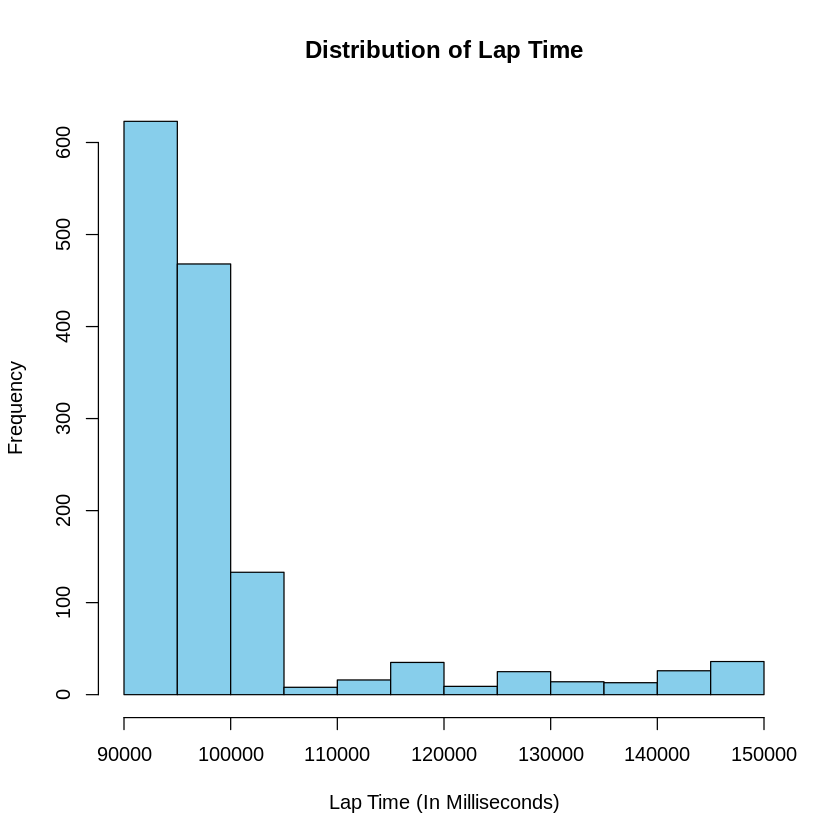

In [ ]:
# Visualizing age distribution
hist(race_cleaned$LapTime_ms, breaks = 10, col = "skyblue",
         main = "Distribution of Lap Time", xlab = "Lap Time (In Milliseconds)")

This histogram is skewed right with a mean around 100000 milliseconds. This makes sense as a higher lap time would likely mean less races won. And with how competitive of a sport F1 is, if you are not performing well, you will be replaced.

Next we will look at a scatterplot.

This box plot displays further statistics for each laptime, to help easily visualize what we were working with.

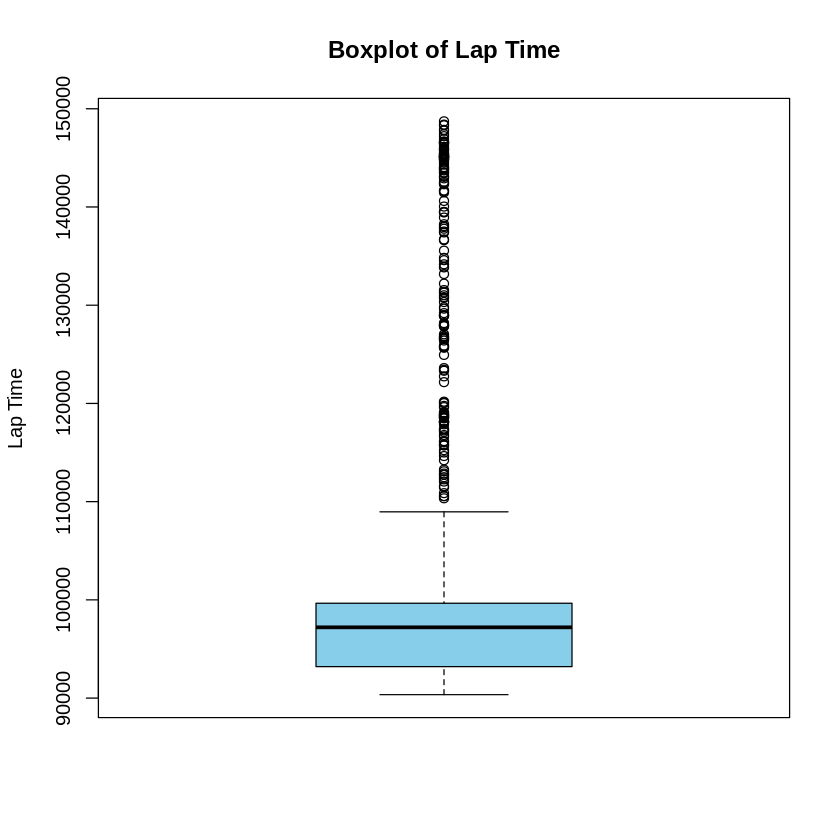

In [ ]:
boxplot(race_cleaned$LapTime_ms,
        main = "Boxplot of Lap Time",
        ylab = "Lap Time",
        col = "skyblue")

The plot reveals there are many outliers above the acceptable limit. This could be a result of many thing whether that be collisions, part failures, or more.

## Correlation Values

Now it was time to find which values we would choose to create our linear regression analysis, by creating a correlation table of each variable in our race_cleaned dataset. First we must load the GGally library to make this possible.

In [ ]:
if(!require(GGally))
    install.packages("GGally")
library(GGally)

Below we were able to succesfully create a correlation chart to help us find which 3 variables had the highest correlation values to laptime_ms

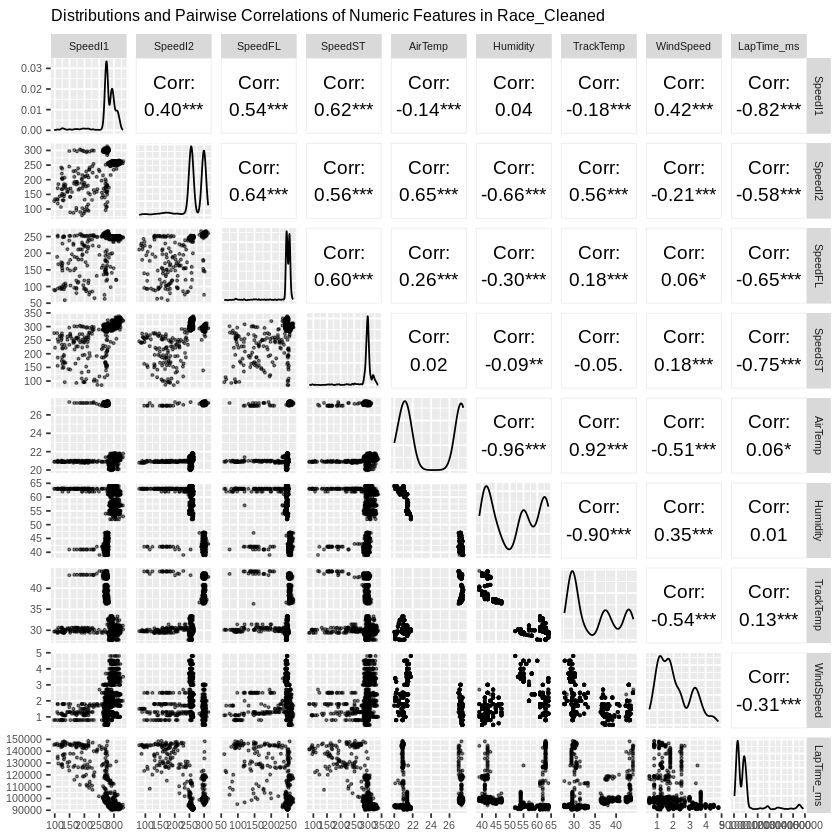

In [ ]:
ggpairs(race_cleaned[, sapply(race_cleaned, is.numeric)],
        lower = list(continuous = wrap("points", alpha = 0.5, size = 0.5)),
        upper = list(continuous = wrap("cor", size = 4, color = "black", method = "pearson", digits = 2)),
        ) +
  ggtitle("Distributions and Pairwise Correlations of Numeric Features in Race_Cleaned") +
  theme(text = element_text(size = 8))  # Adjust font size for better readability

By looking at the chart we can see that LapTime_ms is most highly correlated with SpeedI1, SpeedFL, and SpeedST. SpeedI1 has a correlation of -0.82, SpeedFL has a negative correlation of -0.65, and SpeedST has a correlation of -0.75.

##Linear Regression

We first wanted to find an rmse value to compare our final rmse value to, to know how succesful our prediction model will be. We chose to use the mean for this value, which gave us an rmse value of 12794.65 milliseconds or 12.79 seconds. This value is how accurate the mean model would predict a drivers lap time.

In [ ]:
mean_time <- 100273
mean_predicitions <- rep(mean_time, length(race_cleaned$LapTime_ms))
rmse <- sqrt(mean((race_cleaned$LapTime_ms - mean_predicitions)^2))
rmse

[1] 12794.65

Now it was time to create single and multi linear regression models using our 3 chosen variables from before. We started by training the race_cleaned data to create linear regression plots for both single variables and multi variables.

In [ ]:
set.seed(109)
train_indices <- sample(1:nrow(race_cleaned), 0.8 * nrow(race_cleaned))
train_data <- race_cleaned[train_indices, ]
test_data <- race_cleaned[-train_indices, ]

## Single Linear Regression

First we created a model for SpeedFL to further predict from.

In [ ]:
model <- lm(LapTime_ms ~ SpeedFL, data = train_data)

summary(model)


Call:
lm(formula = LapTime_ms ~ SpeedFL, data = train_data)

Residuals:
   Min     1Q Median     3Q    Max 
-42883  -6113     78   2332  51366 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 163693.787   2408.411   67.97   <2e-16 ***
SpeedFL       -261.733      9.827  -26.63   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 9763 on 1122 degrees of freedom
Multiple R-squared:  0.3874,	Adjusted R-squared:  0.3868 
F-statistic: 709.4 on 1 and 1122 DF,  p-value: < 2.2e-16


This model has an intercept or baseline of 163693.787 and an adjusted r^2 value of 0.3868. This shows a single regression model using SpeedFL isn't the great predictor as the r^2 value is not very high.

Using the trained model, we can now created a plot of the actual lap time correlated with speedFL vs the predicted lap time using the same variable.

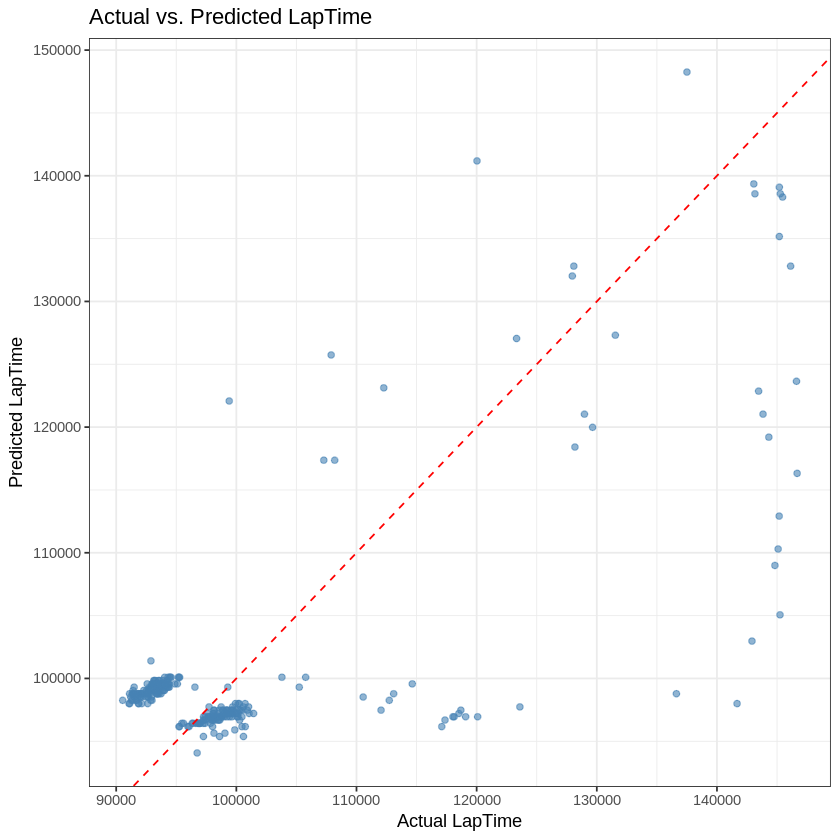

In [ ]:
predictions <- predict(model, newdata = test_data)

plot_data <- data.frame(LapTime_ms = test_data$LapTime_ms, Predictions = predictions)

ggplot(plot_data, aes(x = LapTime_ms, y = Predictions)) +
  geom_point(alpha = 0.6, color = "steelblue") +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "red") +
  labs(title = "Actual vs. Predicted LapTime",
       x = "Actual LapTime",
       y = "Predicted LapTime") +
  theme_bw()

Looking at the chart shows us spread of the points. Many of the points near the higher LapTime are far from the line while some our close to the line near 100000 milliseconds.

To fully evaluate the quality of the model we now can find the rmse value to determine how accurate this plot acctually is. We found the value to be 9634.187 milliseconds.

In [ ]:
rmse <- sqrt(mean((test_data$LapTime_ms - predictions)^2))
rmse

[1] 9634.188

Next we repeated the same process, but now for the SpeedST variable.

In [ ]:
model2 <- lm(LapTime_ms ~ SpeedST, data = train_data)

summary(model2)


Call:
lm(formula = LapTime_ms ~ SpeedST, data = train_data)

Residuals:
   Min     1Q Median     3Q    Max 
-32607  -4411   -979   1462  46490 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 185743.438   2263.644   82.06   <2e-16 ***
SpeedST       -292.167      7.669  -38.10   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 8237 on 1122 degrees of freedom
Multiple R-squared:  0.564,	Adjusted R-squared:  0.5636 
F-statistic:  1451 on 1 and 1122 DF,  p-value: < 2.2e-16


The model using SpeedST has an intercept of 185743.438 with an adjusted r^2 value of 0.5636. Based of these statistics alone this model will hopefully be a better predictor than SpeedFL.

We can now again create a prediction plot based off the speedSt variable.

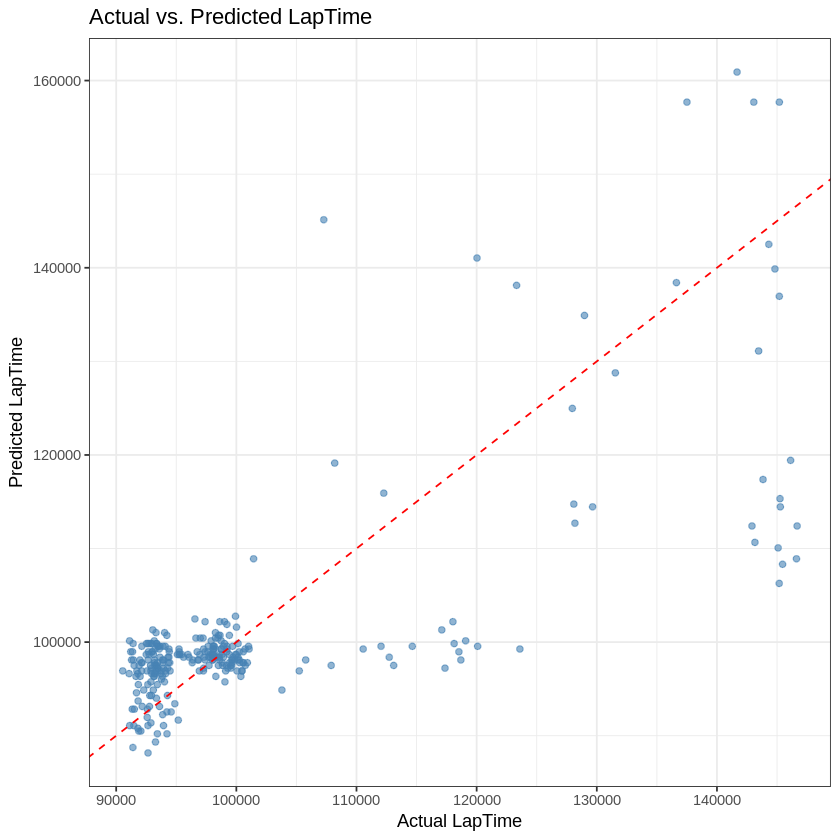

In [ ]:
predictions2 <- predict(model2, newdata = test_data)

plot_data <- data.frame(LapTime_ms = test_data$LapTime_ms, Predictions = predictions2)

ggplot(plot_data, aes(x = LapTime_ms, y = Predictions)) +
  geom_point(alpha = 0.6, color = "steelblue") +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "red") +
  labs(title = "Actual vs. Predicted LapTime",
       x = "Actual LapTime",
       y = "Predicted LapTime") +
  theme_bw()

The spread of the SpeedST prediction seems to be a little better than SpeedFL but still not great. Once again points near the actual lap time of 100000 were closer to line and get farther as the actual lap time increases.

We found this rmse value to be 9247.49 milliseconds off, which is slightly better than our last value.

In [ ]:
rmse <- sqrt(mean((test_data$LapTime_ms - predictions2)^2))
rmse

[1] 9247.494

Finally we created our last single linear regression plot with the highest correlated variable which was SpeedI1.

In [ ]:
model3 <- lm(LapTime_ms ~ SpeedI1, data = train_data)

summary(model3)


Call:
lm(formula = LapTime_ms ~ SpeedI1, data = train_data)

Residuals:
   Min     1Q Median     3Q    Max 
-19667  -3424  -2250    939  47878 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 184154.002   1795.351   102.6   <2e-16 ***
SpeedI1       -301.130      6.379   -47.2   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 7219 on 1122 degrees of freedom
Multiple R-squared:  0.6651,	Adjusted R-squared:  0.6648 
F-statistic:  2228 on 1 and 1122 DF,  p-value: < 2.2e-16


Looking at the intercept again shows a value of 184154.002. The statistics also reveal a 0.6648 r^2 value which is better than both of the last two variables.

Using the trained model for SpeedI1 we can now create the prediction plot.

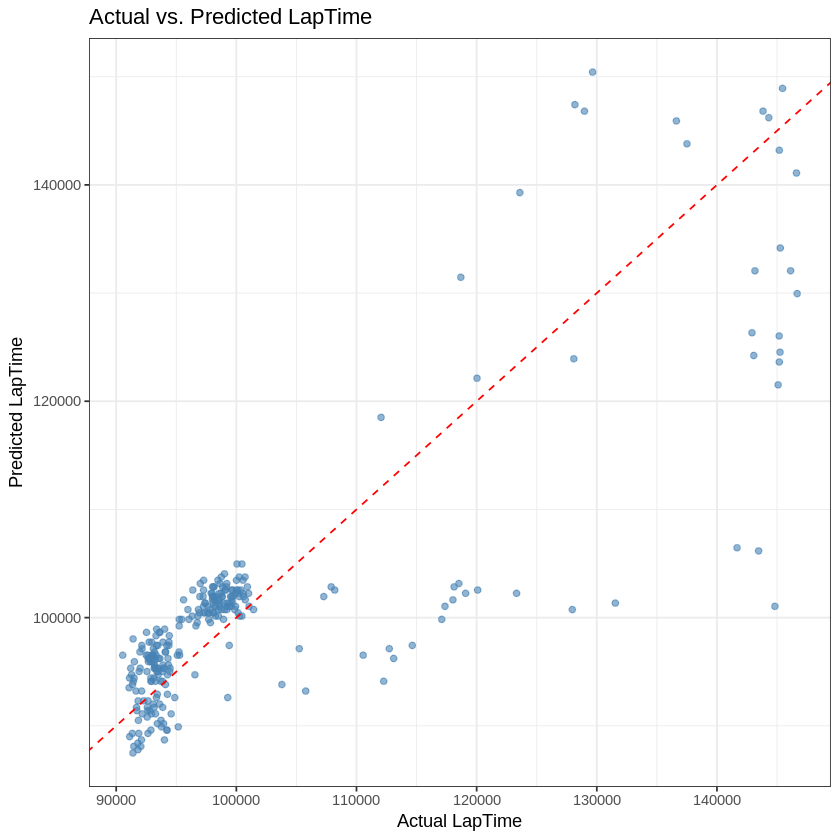

In [ ]:
predictions3 <- predict(model3, newdata = test_data)

plot_data <- data.frame(LapTime_ms = test_data$LapTime_ms, Predictions = predictions3)

ggplot(plot_data, aes(x = LapTime_ms, y = Predictions)) +
  geom_point(alpha = 0.6, color = "steelblue") +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "red") +
  labs(title = "Actual vs. Predicted LapTime",
       x = "Actual LapTime",
       y = "Predicted LapTime") +
  theme_bw()

The model looks similar to the other two but slightly better. The points near lower actual and predicted times are closer to the line than the two plots which is a good sign our predictors are getting better.

We found this rmse value to be 7914.48 milliseconds which is so far the best value we discovered.

In [ ]:
rmse <- sqrt(mean((test_data$LapTime_ms - predictions3)^2))
rmse

[1] 7914.483

## Multi Linear Regression

Now it was time to create a prediction plot for all 3 of the most correlated variables to lap time, to create the most accurate model.

In [ ]:
model4 <- lm(LapTime_ms ~ SpeedI1 + SpeedFL + SpeedST, data = train_data)

summary(model4)


Call:
lm(formula = LapTime_ms ~ SpeedI1 + SpeedFL + SpeedST, data = train_data)

Residuals:
   Min     1Q Median     3Q    Max 
-23532  -2770  -1046   1062  47524 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 209096.832   1786.288 117.057   <2e-16 ***
SpeedI1       -192.609      6.839 -28.162   <2e-16 ***
SpeedFL        -71.520      7.331  -9.755   <2e-16 ***
SpeedST       -129.047      7.436 -17.354   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 5851 on 1120 degrees of freedom
Multiple R-squared:  0.7804,	Adjusted R-squared:  0.7798 
F-statistic:  1326 on 3 and 1120 DF,  p-value: < 2.2e-16


These statistics show the highest r^2 value yet of 0.7798. This makes sense as this model use all 3 of the variables for regression not just one. SpeedI1, SpeedFL, and SpeedST have coeffecients of -192.609, -71.52, and -129.047 respectively. These show how much each variable influence the lap time with the most influential being SpeedI1 which makes sense as it had the highest correlation with our targe variables.

Using the trained model containing all 3 variables we can now create our predicition model.

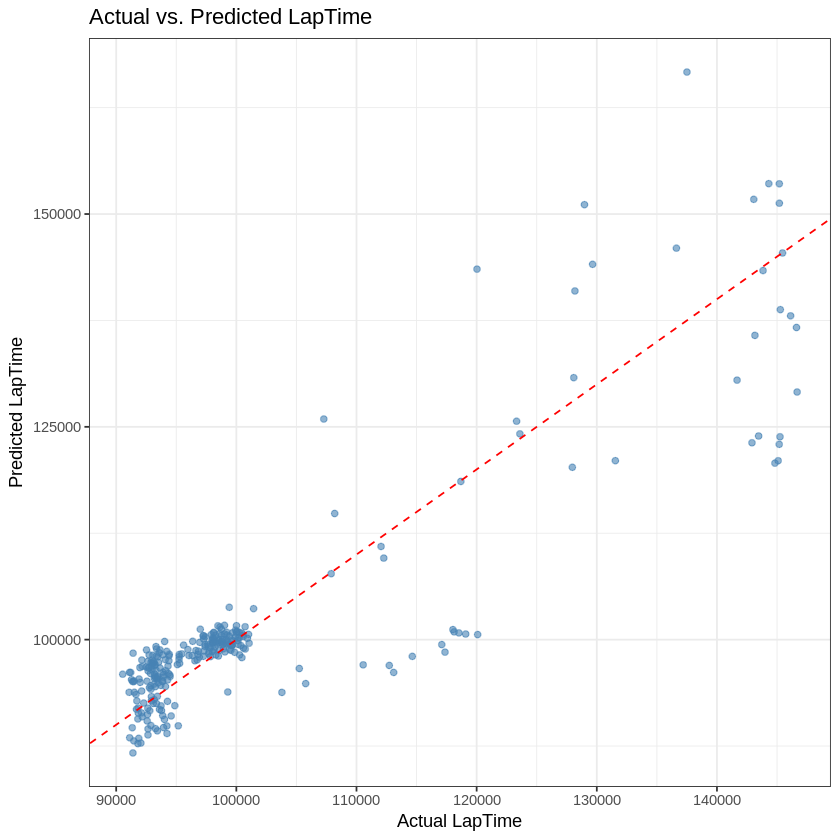

In [ ]:
predictions4 <- predict(model4, newdata = test_data)

plot_data <- data.frame(LapTime_ms = test_data$LapTime_ms, Predictions = predictions4)

ggplot(plot_data, aes(x = LapTime_ms, y = Predictions)) +
  geom_point(alpha = 0.6, color = "steelblue") +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "red") +
  labs(title = "Actual vs. Predicted LapTime",
       x = "Actual LapTime",
       y = "Predicted LapTime") +
  theme_bw()

This scatterplot looks the best of any we've seen so far. The higher actual lap time points are not as far from the line and there is a big grouping in the bottom left corner that is along our line of regression.

Additionally, we found our best rmse value here of 6549.112 milliseconds. This value means our model is able to predcit a drivers lap time within 6.5 seconds.

In [ ]:
rmse <- sqrt(mean((test_data$LapTime_ms - predictions4)^2))
rmse

[1] 6549.112

## Closing

To conclude this portion of the project, we were able to find a model that is more accurate than using the mean model by using the 3 highest correlated values in our data set. These 3 variables make sense because they are all sensors around the track that let you know how fast each driver is going. Drivers will be able to look at our model and realize what portions of the track they need to go faster at to achieve a faster lap time. These sensors are also located at key portions of the track including the speed crossing the finsh line, the speed on the main straight portion of the track, and the speed at the end of the first sector. If drivers are able to focus on maximizing their speed at these 3 points during laps, they will achieve a faster lap time resulting in more success. Therefore, our project has used classification to discover the true importance of starting near the front of the pack. In order to get there however you need to perform well in your qualifying laps. This regression notebook has shown how crucial the speed at the first intermediate, finish line, and speed trap are for a driver's success. This is most likely due to how these portions of the track set the driver up for what is coming next. Knowing how a driver is performing at these points allows for teams and drivers to have make gameplans and strategies so they have higher speed in these crucial areas and in turn have quicker laps and more success over all.